# <span>Worksheet - 4</span>
## <span>Building Fully Connected Neural Networks for Devnagari Handwritten Digit Classification
<small>

**Student Name:** Pratisha Bista  
**ID:** 2408284  
**Group:** L6CG1  

</small>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

Data Preparation

In [3]:
train_dir = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-4/dataset/Train/"
test_dir = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-4/dataset/Test/"
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    """Load Devnagari digit images from folder structure"""
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"\nLoading from {folder}")
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        count = 0

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0
                images.append(img)
                labels.append(label)
                count += 1
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        print(f"Loaded {count} images for class {class_name}")

    return np.array(images), np.array(labels)

In [4]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for Keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"\nTraining set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")


Loading from /content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-4/dataset/Train/
Loaded 1700 images for class digit_0
Loaded 1700 images for class digit_1
Loaded 1700 images for class digit_2
Loaded 1700 images for class digit_3
Loaded 1700 images for class digit_4
Loaded 1700 images for class digit_5
Loaded 1700 images for class digit_6
Loaded 1700 images for class digit_7
Loaded 1700 images for class digit_8
Loaded 1700 images for class digit_9

Loading from /content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-4/dataset/Test/
Loaded 300 images for class digit_0
Loaded 300 images for class digit_1
Loaded 300 images for class digit_2
Loaded 300 images for class digit_3
Loaded 300 images for class digit_4
Loaded 300 images for class digit_5
Loaded 257 images for class digit_6
Loaded 300 images for class digit_7
Loaded 300 images for class digit_8
Loaded 300 images for class digit_9

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (2957, 

Visualise the images

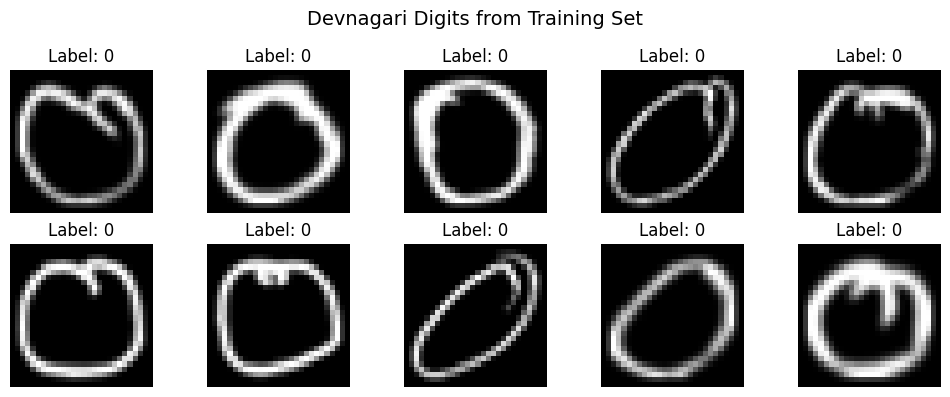

In [5]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Devnagari Digits from Training Set", fontsize=14)
plt.tight_layout()
plt.show()

Build the FCN model

In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),   # 1st hidden: 64 neurons
    keras.layers.Dense(128, activation="sigmoid"),  # 2nd hidden: 128 neurons
    keras.layers.Dense(256, activation="sigmoid"),  # 3rd hidden: 256 neurons
    keras.layers.Dense(10, activation="softmax")    # Output: 10 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compile the Model

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train the Model

In [8]:
batch_size = 128
epochs = 20
validation_split = 0.2

callbacks = [
    keras.callbacks.ModelCheckpoint("best_devnagari_model.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)
]

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4899 - loss: 1.6320 - val_accuracy: 0.0000e+00 - val_loss: 7.4404
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8693 - loss: 0.4885 - val_accuracy: 0.0000e+00 - val_loss: 8.8294
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9332 - loss: 0.2462 - val_accuracy: 0.0000e+00 - val_loss: 9.6590
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9507 - loss: 0.1772 - val_accuracy: 0.0000e+00 - val_loss: 10.0896


Evaluate the model

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.7562
Test Loss: 2.1869


Visualise training progress

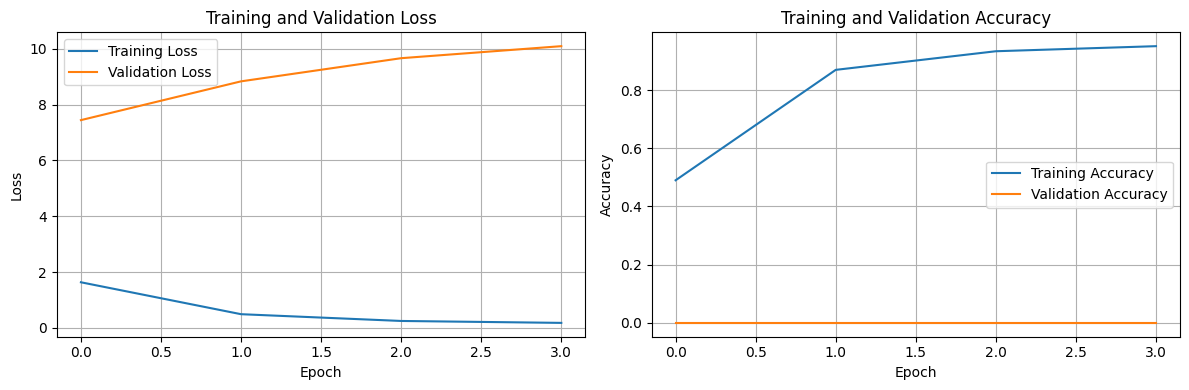

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Save the model

In [11]:
model.save('devnagari_fcn_model_pratisha_bista_2408284.h5')
print("Model saved as 'devnagari_fcn_model_pratisha_bista_2408284.h5'")

from google.colab import files
files.download('devnagari_fcn_model_pratisha_bista_2408284.h5')

Model saved as 'devnagari_fcn_model_pratisha_bista_2408284.h5'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Load and Verify Model

In [12]:
loaded_model = keras.models.load_model('devnagari_fcn_model_pratisha_bista_2408284.h5')
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model accuracy: {loaded_acc:.4f}")

Loaded model accuracy: 0.7562


Make Predictions

In [13]:
predictions = model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("\nSample Predictions (First 20):")
print("-" * 40)
for i in range(20):
    status = "true" if predicted_labels[i] == true_labels[i] else "false"
    print(f"Image {i+1:2d}: Pred={predicted_labels[i]}, True={true_labels[i]} {status}")


Sample Predictions (First 20):
----------------------------------------
Image  1: Pred=0, True=0 true
Image  2: Pred=0, True=0 true
Image  3: Pred=0, True=0 true
Image  4: Pred=0, True=0 true
Image  5: Pred=0, True=0 true
Image  6: Pred=0, True=0 true
Image  7: Pred=0, True=0 true
Image  8: Pred=0, True=0 true
Image  9: Pred=0, True=0 true
Image 10: Pred=0, True=0 true
Image 11: Pred=0, True=0 true
Image 12: Pred=0, True=0 true
Image 13: Pred=0, True=0 true
Image 14: Pred=0, True=0 true
Image 15: Pred=0, True=0 true
Image 16: Pred=0, True=0 true
Image 17: Pred=0, True=0 true
Image 18: Pred=0, True=0 true
Image 19: Pred=0, True=0 true
Image 20: Pred=0, True=0 true


Summary

In [14]:
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Training completed for {len(history.history['loss'])} epochs")
print(f"Model saved and downloaded successfully!")

Final Test Accuracy: 0.7562
Training completed for 4 epochs
Model saved and downloaded successfully!
